## Wavelets Transformation

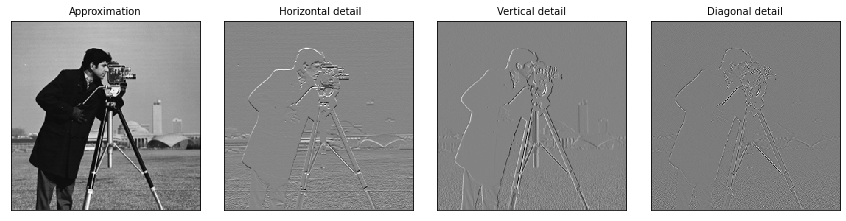

In [3]:
# One level wavelets transform

import numpy as np
import matplotlib.pyplot as plt

import pywt
import pywt.data


# Load image
image = pywt.data.camera()

# Wavelet transform of image, and plot approximation and details
titles = ['Approximation', ' Horizontal detail',
          'Vertical detail', 'Diagonal detail']
coeffs2 = pywt.dwt2(image, 'bior1.3')
LL, (LH, HL, HH) = coeffs2
fig = plt.figure(figsize=(12, 3))
for i, a in enumerate([LL, LH, HL, HH]):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.imshow(a, interpolation="nearest", cmap=plt.cm.gray)
    ax.set_title(titles[i], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
plt.show()

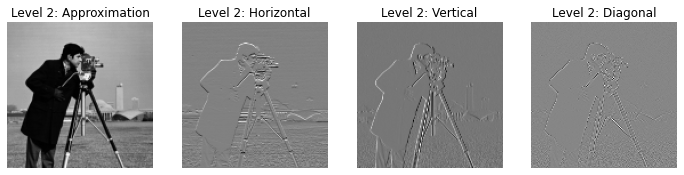

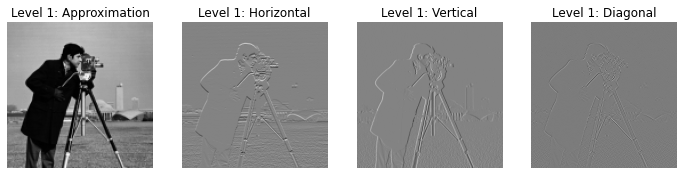

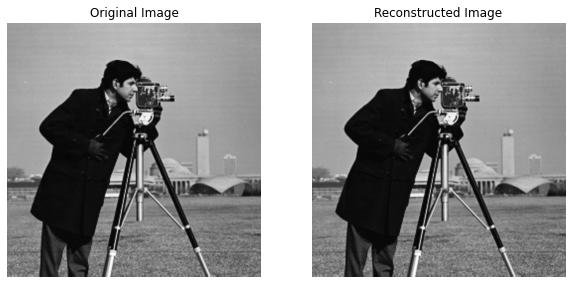

In [4]:
# Perform 2-level wavelet decomposition using 'haar' wavelet
coeffs = pywt.wavedec2(image, 'haar', level=2)

# Extract approximation and detail coefficients
cA2, (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs

# Function to plot wavelet components
def plot_wavelet_components(cA, cH, cV, cD, level):
    fig, axes = plt.subplots(1, 4, figsize=(12, 4))
    axes[0].imshow(cA, cmap='gray')
    axes[0].set_title(f'Level {level}: Approximation')
    
    axes[1].imshow(cH, cmap='gray')
    axes[1].set_title(f'Level {level}: Horizontal')
    
    axes[2].imshow(cV, cmap='gray')
    axes[2].set_title(f'Level {level}: Vertical')
    
    axes[3].imshow(cD, cmap='gray')
    axes[3].set_title(f'Level {level}: Diagonal')
    
    for ax in axes:
        ax.axis('off')
    plt.show()

# Plot Level 2 decomposition
plot_wavelet_components(cA2, cH2, cV2, cD2, level=2)

# Plot Level 1 decomposition
plot_wavelet_components(cA2, cH1, cV1, cD1, level=1)

# Reconstruct the image from wavelet coefficients
reconstructed_image = pywt.waverec2(coeffs, 'haar')

# Display original and reconstructed images
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(reconstructed_image, cmap='gray')
ax[1].set_title('Reconstructed Image')
ax[1].axis('off')

plt.show()

### Watermarking

General steps:

Perform DWT on the original image (e.g., using Haar wavelet) to get approximation (LL) and detail (LH, HL, HH) subbands.

Embed the watermark into one of the subbands (usually LL or HH for robustness vs. visibility trade-off).

Apply inverse DWT (IDWT) to reconstruct the watermarked image.

Extract the watermark by applying DWT to the watermarked image and subtracting from the original wavelet coefficients.

In [5]:
import numpy as np
import pywt
import cv2
import matplotlib.pyplot as plt

def apply_dwt(image):
    """Perform 2-level DWT on the image."""
    coeffs = pywt.wavedec2(image, 'haar', level=2)
    return coeffs

def embed_watermark(image, watermark, alpha=0.1):
    """Embed watermark into the wavelet coefficients of the image."""
    coeffs = apply_dwt(image)
    cA2, (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs
    
    # Resize watermark to match cA2 size
    watermark_resized = cv2.resize(watermark, (cA2.shape[1], cA2.shape[0]))
    
    # Embed watermark in the LL subband
    cA2_wm = cA2 + alpha * watermark_resized
    
    # Reconstruct the image using IDWT
    watermarked_coeffs = (cA2_wm, (cH2, cV2, cD2), (cH1, cV1, cD1))
    watermarked_image = pywt.waverec2(watermarked_coeffs, 'haar')
    
    return np.clip(watermarked_image, 0, 255).astype(np.uint8), watermark_resized

def extract_watermark(original_image, watermarked_image, alpha=0.1):
    """Extract the watermark by comparing DWT coefficients of original and watermarked images."""
    coeffs_orig = apply_dwt(original_image)
    coeffs_wm = apply_dwt(watermarked_image)
    
    cA2_orig, _, _ = coeffs_orig
    cA2_wm, _, _ = coeffs_wm
    
    # Extract watermark
    extracted_wm = (cA2_wm - cA2_orig) / alpha
    return np.clip(extracted_wm, 0, 255).astype(np.uint8)

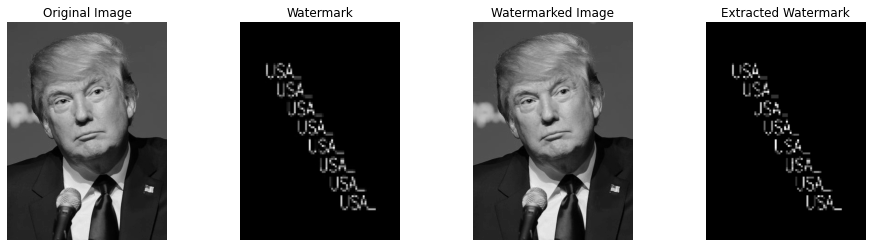

In [22]:
# Load images
image = cv2.imread('lab9/Trump.jpg', cv2.IMREAD_GRAYSCALE)
watermark = cv2.imread('lab9/watermark.jpg', cv2.IMREAD_GRAYSCALE)

# Embed watermark
watermarked_image, watermark_resized = embed_watermark(image, watermark)

# Extract watermark
extracted_watermark = extract_watermark(image, watermarked_image)

# Display results
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(watermark_resized, cmap='gray')
ax[1].set_title('Watermark')
ax[1].axis('off')

ax[2].imshow(watermarked_image, cmap='gray')
ax[2].set_title('Watermarked Image')
ax[2].axis('off')

ax[3].imshow(extracted_watermark, cmap='gray')
ax[3].set_title('Extracted Watermark')
ax[3].axis('off')

plt.show()

True